Loaded from NPZ (c001_Time, sst_Voltage); N=150000 samples; duration ≈ 3.000 s


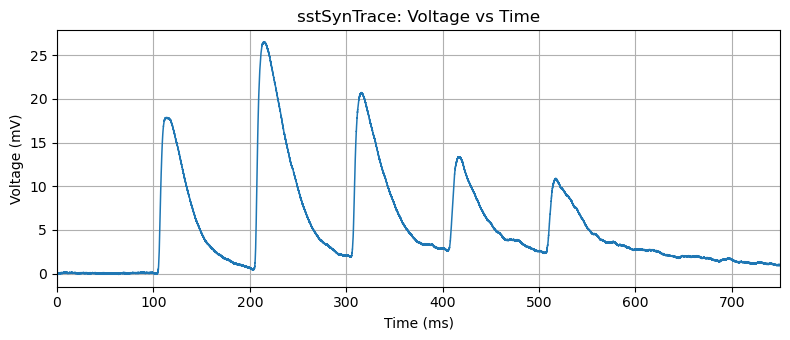

In [1]:
# Self-contained plotting cell for sstSynTrace
# - Priority: NPZ > CSV > PKL
# - Uses time in seconds → ms; voltage in volts → mV

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

DS_DIR = "/home/hrbncv/PV-SST/single_cells/Madhu_Data/MAT_Analysis/processed/sstSynTrace"
STEM   = "sstSynTrace"

def load_series(ds_dir, stem):
    # ---- NPZ ----
    npz = f"{ds_dir}/{stem}.npz"
    try:
        with np.load(npz) as z:
            keys = list(z.files)
            if keys:
                tkey = next((k for k in ("c001_Time","Time","time","t") if k in keys), None)
                if tkey is None:
                    tkey = next((k for k in keys if isinstance(k,str) and "time" in k.lower()), None)
                vkey = "sst_Voltage" if "sst_Voltage" in keys else next((k for k in keys if isinstance(k,str) and "voltage" in k.lower()), None)
                if tkey and vkey:
                    t = np.asarray(z[tkey]).astype(float).ravel()
                    v = np.asarray(z[vkey]).astype(float).ravel()
                    return t, v, f"NPZ ({tkey}, {vkey})"
    except Exception:
        pass
    # ---- CSV ----
    csv = f"{ds_dir}/{stem}.csv"
    try:
        df = pd.read_csv(csv)
        tcol = next((c for c in ("c001_Time","Time","time","t") if c in df.columns), None)
        if tcol is None:
            tcol = next((c for c in df.columns if "time" in c.lower()), None)
        vcol = "sst_Voltage" if "sst_Voltage" in df.columns else next((c for c in df.columns if "voltage" in c.lower()), None)
        if tcol and vcol:
            t = df[tcol].to_numpy(dtype=float).ravel()
            v = df[vcol].to_numpy(dtype=float).ravel()
            return t, v, f"CSV ({tcol}, {vcol})"
    except Exception:
        pass
    # ---- PKL ----
    pkl = f"{ds_dir}/{stem}.pkl"
    try:
        with open(pkl, "rb") as f:
            obj = pickle.load(f)
        if isinstance(obj, dict):
            keys = list(obj.keys())
            tkey = next((k for k in ("c001_Time","Time","time","t") if k in keys), None)
            if tkey is None:
                tkey = next((k for k in keys if isinstance(k,str) and "time" in k.lower()), None)
            vkey = "sst_Voltage" if "sst_Voltage" in keys else next((k for k in keys if isinstance(k,str) and "voltage" in k.lower()), None)
            if tkey and vkey:
                t = np.asarray(obj[tkey]).astype(float).ravel()
                v = np.asarray(obj[vkey]).astype(float).ravel()
                return t, v, f"PKL ({tkey}, {vkey})"
    except Exception:
        pass
    raise RuntimeError("No time/voltage pair found in NPZ/CSV/PKL.")

t, v, src = load_series(DS_DIR, STEM)
t_ms  = t * 1e3
v_mV  = v * 1e3

print(f"Loaded from {src}; N={t.size} samples; duration ≈ {t[-1]-t[0]:.3f} s")

plt.figure(figsize=(8,3.5))
plt.plot(t_ms, v_mV, lw=1.1)
plt.xlabel("Time (ms)")
plt.xlim(0,750)
plt.ylabel("Voltage (mV)")
plt.title(f"{STEM}: Voltage vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()
